## Objective 
To apply and compare different feature selection techniques and evaluate 
their impact on model performance. 
### Task 
Using the Pima Indians Diabetes dataset, perform feature selection 
using the following techniques discussed in the lecture material 
(download the dataset from Kaggle) 
Instructions 
1. Dataset Preparation 
Load the dataset into Python. 
Separate the dataset into features XXX and target variable yyy. 
Perform any necessary preprocessing (e.g., handling missing values, 
feature scaling where required). 
2. Univariate Feature Selection 
Apply SelectKBest with the chi-squared (chi²) test. 
Select the top 4 features. 
Display the selected features and their scores. 
3. Recursive Feature Elimination (RFE) 
Use Logistic Regression as the base estimator. 
Apply RFE to select the top 3 features. 
List the selected features. 
4. Principal Component Analysis (PCA) 
Apply PCA to reduce the dataset to 3 principal components. 
Report the explained variance ratio of each component. 
5. Feature Importance 
Train an ExtraTreesClassifier on the dataset. 
Compute and rank feature importance scores. 
Identify the top 3 most important features. 
6. Model Evaluation 
Train a Logistic Regression classifier using: 
- (a) All original features 
- (b) Features selected using Univariate Selection 
- Features selected using RFE 
- Compare classification accuracy for each case. 

Submission Requirements 
Python code (well-commented). 
Tables or printed outputs showing selected features and scores. 
© Copyright 2025 MIVA Open University All Rights Reserved | 3.

A brief discussion (5–7 sentences) comparing the results of the 
different feature selection techniques and their effect on model 
performance. 
Assessment Focus 
Correct application of feature selection methods 
Interpretation of outputs 
Clarity of results and discussion

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sklearn
import os 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

## 1. data preparation

In [2]:
# import the Pima Indiansdata from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1


In [3]:
# Load the dataset
df = pd.read_csv(os.path.join(path, 'diabetes.csv'))

# Display the first few rows to verify
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# separate the features and target variable
X = df.drop('Outcome', axis=1)  # Features
y = df['Outcome']  # Target variable


In [5]:
# y count 
y_count = y.value_counts()
print("Target Variable Distribution:")
print(y_count)

Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


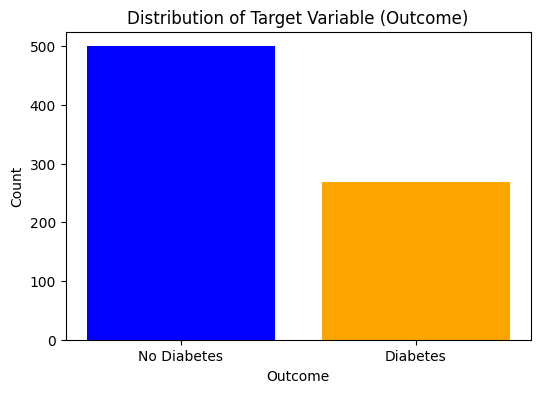

In [6]:
# plot the distribution of the target variable
plt.figure(figsize=(6, 4))
plt.bar(y_count.index, y_count.values, color=['blue', 'orange'])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Target Variable (Outcome)')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

In [7]:
# Check for missing values
print(X.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [8]:
# check for columns with zeros 
print((X == 0).sum())


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [9]:
# Handle missing values (replace 0s in certain columns with NaN and impute)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[cols_with_zeros] = X[cols_with_zeros].replace(0, np.nan)
X.fillna(X.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


In [10]:
# check for columns with zeros 
print((X == 0).sum())

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [11]:
# feature scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  


In [12]:
X_scaled

array([[ 0.63994726,  0.86604475, -0.03198993, ...,  0.16661938,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20506583, -0.5283186 , ..., -0.85219976,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.01666174, -0.69376149, ..., -1.33250021,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.02157407, -0.03198993, ..., -0.910418  ,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14279979, -1.02464727, ..., -0.34279019,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94206766, -0.19743282, ..., -0.29912651,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [13]:
# display for where X values are less than 0
print(X_scaled[X_scaled < 0])

[-0.03198993 -0.18154124 -0.84488505 ... -0.29912651 -0.47378505
 -0.87137393]


## 2. Univariate Feature Seletion

In [14]:
# Split data to prevent data leakage during scaling and selection

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Original features: {X.columns.tolist()}\n")

# --- APPROACH A: Using chi2 (Requires non-negative data) ---
# We use MinMaxScaler to scale data into the [0, 1] range.
pipeline_chi2 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('selector', SelectKBest(chi2, k=3)), # Select top 4 features
    ('classifier', LogisticRegression(solver='liblinear'))
])

pipeline_chi2.fit(X_train, y_train)
print(f"Chi-Square Pipeline Accuracy: {pipeline_chi2.score(X_test, y_test):.4f}")

# Get the features selected by the chi2 pipeline
mask_chi2 = pipeline_chi2.named_steps['selector'].get_support()
selected_feats_chi2 = X.columns[mask_chi2]
print(f"Features selected by Chi2: {selected_feats_chi2.tolist()}\n")

# display the features with their chi2 scores
chi2_scores = pipeline_chi2.named_steps['selector'].scores_
for feat, score in zip(X.columns, chi2_scores):
    print(f"{feat}: {score:.4f}")


Original features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Chi-Square Pipeline Accuracy: 0.7229
Features selected by Chi2: ['Pregnancies', 'Glucose', 'Age']

Pregnancies: 4.8702
Glucose: 13.0588
BloodPressure: 0.5016
SkinThickness: 1.2730
Insulin: 2.3336
BMI: 3.4449
DiabetesPedigreeFunction: 1.4147
Age: 5.2312


## 3. Recursive Feature Elimination RFE

In [15]:
base_estimator = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Apply RFE and select the top 3 features as per the instructions
rfe = RFE(estimator=base_estimator, n_features_to_select=3)
rfe_fit = rfe.fit(X_scaled, y)


feature_names = X.columns 

# List the selected features
# rfe_fit.support_ returns a boolean array (True for selected features)
selected_mask_rfe = rfe_fit.support_
selected_features_rfe = feature_names[selected_mask_rfe]

print("--- Recursive Feature Elimination (RFE) Results ---")
print(f"Target number of features: {rfe_fit.n_features_}")
print(f"The 3 features selected by RFE are: {list(selected_features_rfe)}\n")

# display the ranking of all features to see what was dropped first
# Ranking of 1 means the feature was selected.
feature_rankings = pd.DataFrame({
    'Feature': feature_names, 
    'Ranking': rfe_fit.ranking_
}).sort_values(by='Ranking')

print("Feature Rankings (1 = Selected, higher number = dropped earlier):")
print(feature_rankings)


--- Recursive Feature Elimination (RFE) Results ---
Target number of features: 3
The 3 features selected by RFE are: ['Pregnancies', 'Glucose', 'BMI']

Feature Rankings (1 = Selected, higher number = dropped earlier):
                    Feature  Ranking
0               Pregnancies        1
1                   Glucose        1
5                       BMI        1
6  DiabetesPedigreeFunction        2
7                       Age        3
2             BloodPressure        4
4                   Insulin        5
3             SkinThickness        6


## 4. Principal Component Analysis

In [16]:
# using Principal Component Analysis (PCA) for dimensionality reduction 

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

loadings = pca.components_

feature_names = [f'Feature_{i+1}' for i in range(X_scaled.shape[1])]

# 4. Create the DataFrame
pca_df = pd.DataFrame(
    loadings, 
    columns=feature_names, 
    index=[f'PC{i+1}' for i in range(n_components)]
)

print(pca_df.T.head(3))

# model accuracy 




                PC1      PC2       PC3
Feature_1  0.301434  0.55796 -0.024609
Feature_2  0.423980 -0.08205  0.441560
Feature_3  0.377177  0.17198 -0.305323


## 5. Feature Importance

In [17]:
#Train an ExtraTreesClassifier on the dataset


model = ExtraTreesClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"ExtraTreesClassifier Accuracy: {model.score(X_test, y_test):.3f}")

# Compute and rank feature importance scores.
feature_importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print("\nFeature Importance Scores:")
print(importance_df)

ExtraTreesClassifier Accuracy: 0.753

Feature Importance Scores:
                    feature  importance
1                   Glucose    0.239804
5                       BMI    0.138203
7                       Age    0.130242
6  DiabetesPedigreeFunction    0.113760
0               Pregnancies    0.106718
2             BloodPressure    0.093949
4                   Insulin    0.090655
3             SkinThickness    0.086670


In [18]:
# Identify the top 3 most important features. 
top_3_features = importance_df.head(3)['feature'].tolist()
print(f"Top 3 Important Features: {top_3_features}")

Top 3 Important Features: ['Glucose', 'BMI', 'Age']


## 6 Model Evaluation

In [19]:
# --- 2. Train and Evaluate BASELINE Model (All Features) ---
print("--- Training Model with ALL 8 Features ---")

# Create a pipeline to handle missing data, scale, and classify
# We use StandardScaler because it's generally better for Logistic Regression
baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
baseline_pipe.fit(X_train, y_train)

# Evaluate the model
y_pred_baseline = baseline_pipe.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print("Classification Report (All Features):")
print(classification_report(y_test, y_pred_baseline))
print("\n" + "="*50 + "\n")


--- Training Model with ALL 8 Features ---
Baseline Accuracy: 0.7446
Classification Report (All Features):
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       150
           1       0.67      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.74      0.74      0.74       231





In [20]:
# --- 3. Train and Evaluate Model with SelectKBest Features ---
print("--- Training Model with Top 4 (SelectKBest) Features ---")

# First, we need to formally identify the top 4 features using the training data
# We use a temporary pipeline for this to ensure correct processing
selection_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()), # Use MinMaxScaler because chi2 requires non-negative values
    ('selector', SelectKBest(score_func=chi2, k=4))
])

selection_pipe.fit(X_train, y_train)

# Get the names of the selected features
selected_mask = selection_pipe.named_steps['selector'].get_support()
selected_features = X_train.columns[selected_mask]
print(f"Features selected by SelectKBest: {list(selected_features)}\n")

# Now, create new training and testing sets with only these features
X_train_kbest = X_train[selected_features]
X_test_kbest = X_test[selected_features]

# Create and train the final model pipeline on the selected features
kbest_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

kbest_pipe.fit(X_train_kbest, y_train)

# Evaluate the model
y_pred_kbest = kbest_pipe.predict(X_test_kbest)
kbest_accuracy = accuracy_score(y_test, y_pred_kbest)

print(f"SelectKBest Model Accuracy: {kbest_accuracy:.4f}")
print("Classification Report (Top 4 Features):")
print(classification_report(y_test, y_pred_kbest))

--- Training Model with Top 4 (SelectKBest) Features ---
Features selected by SelectKBest: ['Pregnancies', 'Glucose', 'BMI', 'Age']

SelectKBest Model Accuracy: 0.7359
Classification Report (Top 4 Features):
              precision    recall  f1-score   support

           0       0.77      0.84      0.81       150
           1       0.65      0.54      0.59        81

    accuracy                           0.74       231
   macro avg       0.71      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



In [21]:
print("--- Training Model with Top 3 (RFE) Features ---")

# 1. Setup the RFE Selector Pipeline to determine the top 3 features on the training data
rfe_selector = RFE(
    estimator=LogisticRegression(solver='liblinear', random_state=42, max_iter=1000), 
    n_features_to_select=3
)

rfe_setup_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()), # Logistic Regression relies heavily on scaling
    ('selector', rfe_selector)
])

# Fit the setup pipeline to identify the features
rfe_setup_pipe.fit(X_train, y_train)

# Extract the selected feature names
selected_mask_rfe = rfe_setup_pipe.named_steps['selector'].get_support()
selected_features_rfe = X_train.columns[selected_mask_rfe]
print(f"Features selected by RFE: {list(selected_features_rfe)}\n")

# 2. Filter the training and testing sets to only include the RFE features
X_train_rfe = X_train[selected_features_rfe]
X_test_rfe = X_test[selected_features_rfe]

# 3. Create and train the final evaluation pipeline
rfe_eval_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

rfe_eval_pipe.fit(X_train_rfe, y_train)

# 4. Predict and Evaluate
y_pred_rfe = rfe_eval_pipe.predict(X_test_rfe)
rfe_accuracy = accuracy_score(y_test, y_pred_rfe)

print(f"RFE Model Accuracy: {rfe_accuracy:.4f}")
print("Classification Report (Top 3 RFE Features):")
print(classification_report(y_test, y_pred_rfe))

--- Training Model with Top 3 (RFE) Features ---
Features selected by RFE: ['Pregnancies', 'Glucose', 'BMI']

RFE Model Accuracy: 0.7403
Classification Report (Top 3 RFE Features):
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       150
           1       0.66      0.54      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231

